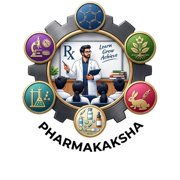

# BP201T · Unit III — Sampling and Statistical Inference
**Pharmakaksha · Learn · Grow · Achieve**
*Applied Biostatistics and Data Analytics for Pharmaceutical Sciences · B.Pharm Semester II · PCI NEP 2020*

This notebook contains every example and demo from the Unit III study notes, slides and video, in the same order.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajreddys/learn-pharmakaksha-site/blob/main/content/BP201T%20Applied%20Biostatistics%20and%20Data%20Analytics%20for%20Pharmaceutical%20Sciences%20%28Theory%29/BP201T_Unit3_Sampling_and_Inference.ipynb)

**How to use this notebook**
1. Open it at [learn.pharmakaksha.com](https://learn.pharmakaksha.com/notebooks/index.html?path=BP201T%20Applied%20Biostatistics%20and%20Data%20Analytics%20for%20Pharmaceutical%20Sciences%20%28Theory%29/BP201T_Unit3_Sampling_and_Inference.ipynb) (no login needed) or in **Google Colab** with the button above (sign in with Google; use **File → Save a copy in Drive** to keep your work).
2. Click a code cell and press **Shift + Enter** to run it. Run the cells from top to bottom.
3. The practice datasets sit next to this notebook. In Colab they are read from GitHub automatically.

**Using learn.pharmakaksha.com**
Python runs inside your web browser, so nothing is installed and nothing is sent to a server. Use an up-to-date Chrome, Edge, Firefox or Safari, on a laptop or a phone.
- **The first run is slow.** The first time you run a cell, the browser downloads Python, which can take 10–30 seconds. The first `import scipy` takes a few seconds more. After that, cells run quickly.
- **Check the kernel.** *Python (Pyodide)* appears at the top right. A filled circle means Python is busy, and an empty circle means it is ready.
- **If a cell hangs** or you want a fresh start, use **Kernel → Restart Kernel**, then run the cells from the top again.
- **Save your work.** Press **Ctrl + S** (**Cmd + S** on a Mac). Your work is saved in this browser only. It will not appear on another device, and clearing your browsing data or using a private/incognito window erases it. Use **File → Download** to keep a copy.
- **Start over.** The site keeps opening your saved copy of the notebook. To get the original version back, go to the file list, tick the notebook, click **Delete** and reload the page.

> All datasets are fictional teaching data. The analyses are for learning statistics only. They are not clinical or regulatory decisions.

## 3.1 Population and sample
The **population** is everyone we want to draw conclusions about (all adults with hypertension in India). A **sample** is the smaller group we actually study (120 patients in our trial). A number that describes the population is a **parameter** (μ, σ, p); the same number calculated from a sample is a **statistic** (x̄, s, p̂), and we use statistics to estimate parameters.

To *see* sampling at work we create an imaginary population of 100,000 hospital stays (in days). Real stays are right-skewed: most patients go home in a few days, a few stay for weeks.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/ajreddys/learn-pharmakaksha-site/main/content/BP201T%20Applied%20Biostatistics%20and%20Data%20Analytics%20for%20Pharmaceutical%20Sciences%20%28Theory%29/"

def load(name):
    """Read a practice CSV from this folder, or from GitHub (Colab)."""
    if os.path.exists(name):
        return pd.read_csv(name)
    return pd.read_csv(URL + name)

In [ ]:
from scipy import stats

rng = np.random.default_rng(2026)
population = rng.exponential(scale=5, size=100_000) + 1      # length of stay, days
print("Population mean μ =", round(population.mean(), 2), " SD σ =", round(population.std(), 2))

sample = rng.choice(population, size=30, replace=False)       # one simple random sample
print("Sample mean x̄   =", round(sample.mean(), 2), " SD s =", round(sample.std(ddof=1), 2))

## 3.2 Sampling methods in clinical research
| Method | How it works | Example |
|---|---|---|
| **Simple random** | Every member has an equal chance | Pick 30 of 500 prescriptions by random numbers |
| **Systematic** | Every k-th member after a random start | Audit every 10th dispensing record |
| **Stratified** | Divide into groups (strata), sample randomly within each | Sample men and women in proportion |
| **Cluster** | Randomly choose whole groups | Choose 5 hospitals, include all their patients |
| **Convenience** | Whoever is easy to reach (non-random) | Patients attending one OPD on Monday |

In a randomised controlled trial (RCT), patients are also **randomly allocated** to drug or placebo so the two groups are alike except for the treatment.

In [ ]:
records = pd.DataFrame({"record_id": range(1, 501),
                        "ward": rng.choice(["Medical", "Surgical", "Paediatric"], 500, p=[0.5, 0.3, 0.2])})

simple = records.sample(n=30, random_state=1)
start = 3; systematic = records.iloc[start::10]                                 # every 10th record
stratified = records.groupby("ward", group_keys=False).sample(frac=0.06, random_state=1)

print("Population:", records["ward"].value_counts(normalize=True).round(2).to_dict())
print("Simple:    ", simple["ward"].value_counts(normalize=True).round(2).to_dict())
print("Stratified:", stratified["ward"].value_counts(normalize=True).round(2).to_dict())
print("Sizes:", len(simple), len(systematic), len(stratified))

## 3.3 Sampling error and bias
**Sampling error** is the natural chance difference between a sample statistic and the population parameter. It gets smaller as the sample gets larger.

**Bias** is a *systematic* error that pushes results in one direction. A bigger sample does **not** fix bias. Examples: selection bias (only healthy volunteers), measurement bias (an uncalibrated BP machine reading 5 mmHg high), recall bias, loss to follow-up.

In [ ]:
for n in [10, 30, 100, 1000]:
    means = [rng.choice(population, n).mean() for _ in range(1000)]
    print(f"n = {n:4d}: sample means range {min(means):5.2f} to {max(means):5.2f},  SD of means = {np.std(means):.2f}")

# Bias: sampling only the shortest stays (e.g. a day-care unit) gives a wrong answer at any n
biased = np.sort(population)[:50_000]
print("Biased sample mean (n = 1000):", round(rng.choice(biased, 1000).mean(), 2), " vs μ =", round(population.mean(), 2))

## 3.4 The Central Limit Theorem (CLT)
**CLT:** whatever the shape of the population, the distribution of **sample means** becomes approximately **normal** as the sample size grows (n ≥ 30 is a common rule of thumb). Its centre is μ and its spread is the **standard error**, SE = σ / √n.

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(14, 3.6))
ax[0].hist(population, bins=60, color="#12303A")
ax[0].set_title("Population (skewed)")
for i, n in enumerate([2, 10, 30], start=1):
    means = [rng.choice(population, n).mean() for _ in range(3000)]
    ax[i].hist(means, bins=40, color="#1F8A70", edgecolor="white")
    ax[i].set_title(f"Means of n = {n}")
for a in ax: a.set_xlabel("Days"); a.set_yticks([])
plt.suptitle("Central Limit Theorem: sample means become normal", y=1.03)
plt.tight_layout(); plt.show()

print("Theory: SE for n = 30 =", round(population.std() / np.sqrt(30), 2))

## 3.5 Confidence intervals
A **95% confidence interval (CI)** is a range, built from the sample, that would contain the true population mean in 95% of repeated studies.

**CI = x̄ ± t × SE**, with SE = s / √n and t from the t-distribution with n − 1 degrees of freedom (t ≈ 2.0 for n = 60; for large samples z = 1.96).

What is the mean fall in SBP for patients on the drug in `bp_trial.csv`?

In [ ]:
bp = load("bp_trial.csv")
drug = bp[bp["group"] == "Drug"]["sbp_drop"]
placebo = bp[bp["group"] == "Placebo"]["sbp_drop"]

n, mean, s = len(drug), drug.mean(), drug.std()
se = s / np.sqrt(n)
t_crit = stats.t.ppf(0.975, df=n - 1)
print(f"n = {n}, mean = {mean:.2f}, SD = {s:.2f}, SE = {se:.2f}, t = {t_crit:.3f}")
print(f"95% CI by formula: {mean - t_crit * se:.2f} to {mean + t_crit * se:.2f} mmHg")
print("95% CI by SciPy:  ", np.round(stats.t.interval(0.95, df=n - 1, loc=mean, scale=se), 2))

Does "95%" really mean 95%? Draw 100 samples of n = 30 from our population and count how many CIs contain μ.

In [ ]:
mu = population.mean(); hits = 0
plt.figure(figsize=(8, 5))
for i in range(100):
    smp = rng.choice(population, 30)
    lo, hi = stats.t.interval(0.95, 29, smp.mean(), smp.std(ddof=1) / np.sqrt(30))
    ok = lo <= mu <= hi; hits += ok
    plt.plot([lo, hi], [i, i], color="#1F8A70" if ok else "#E07A2E", linewidth=1.5)
plt.axvline(mu, color="#12303A", linewidth=2, label=f"True mean μ = {mu:.2f}")
plt.xlabel("Length of stay (days)"); plt.ylabel("Sample number"); plt.yticks([])
plt.title(f"{hits} of 100 confidence intervals contain μ (orange = missed)")
plt.legend(); plt.show()

## 3.6 Hypothesis testing: H₀ and H₁
1. State the **null hypothesis H₀** (no effect, no difference) and the **alternative H₁** (there is an effect).
2. Choose the **significance level α** (usually 0.05).
3. Compute a **test statistic** and its **p-value** from the data.
4. If p < α, **reject H₀**; otherwise **fail to reject H₀** (we never "prove" H₀).

**Example 1 (one-sample t-test).** Tablets in batch B are labelled 250 mg. H₀: μ = 250 mg; H₁: μ ≠ 250 mg.

In [ ]:
tw = load("tablet_weights.csv")
b = tw[tw["batch"] == "B"]["weight_mg"]
t_stat, p_val = stats.ttest_1samp(b, popmean=250)
print(f"Batch B mean = {b.mean():.2f} mg, t = {t_stat:.2f}, p = {p_val:.4f}")
print("Reject H0" if p_val < 0.05 else "Fail to reject H0")

a = tw[tw["batch"] == "A"]["weight_mg"]
t_a, p_a = stats.ttest_1samp(a, 250)
print(f"Batch A mean = {a.mean():.2f} mg, t = {t_a:.2f}, p = {p_a:.4f}")

**Example 2 (two-sample t-test).** Does the drug lower SBP more than placebo? H₀: μ_drug = μ_placebo; H₁: μ_drug ≠ μ_placebo. Welch's t-test (`equal_var=False`) does not assume equal SDs.

In [ ]:
t_stat, p_val = stats.ttest_ind(drug, placebo, equal_var=False)
diff = drug.mean() - placebo.mean()
print(f"Drug {drug.mean():.2f} vs placebo {placebo.mean():.2f} mmHg; difference {diff:.2f} mmHg")
print(f"t = {t_stat:.2f}, p = {p_val:.2e}")

se_diff = np.sqrt(drug.var() / len(drug) + placebo.var() / len(placebo))
print(f"Approximate 95% CI of the difference: {diff - 1.96 * se_diff:.2f} to {diff + 1.96 * se_diff:.2f} mmHg")

## 3.7 Type I and Type II errors
| | H₀ really true (drug useless) | H₀ really false (drug works) |
|---|---|---|
| **Reject H₀** | **Type I error** (false positive), probability α | Correct: **power** = 1 − β |
| **Fail to reject H₀** | Correct | **Type II error** (false negative), probability β |

A simulation shows both. First, 2,000 imaginary trials of a **useless** drug (no true difference):

In [ ]:
def trial(true_effect, n, sd=8):
    d = rng.normal(true_effect, sd, n); p = rng.normal(0, sd, n)
    return stats.ttest_ind(d, p).pvalue

p_null = [trial(0, 30) for _ in range(2000)]
print("Useless drug: significant in", round(100 * np.mean(np.array(p_null) < 0.05), 1), "% of trials  (Type I error ≈ α)")

for n in [10, 20, 30, 60]:
    p_eff = [trial(5, n) for _ in range(2000)]
    power = np.mean(np.array(p_eff) < 0.05)
    print(f"Drug lowers SBP by 5 mmHg, n = {n:2d} per group: power {power:.0%}, Type II error {1 - power:.0%}")

## 3.8 p-values and significance
The **p-value** is the probability of getting a result at least as extreme as the one observed **if H₀ were true**.
- A small p (< 0.05) means the data would be surprising under H₀, so we reject H₀.
- p is **not** the probability that H₀ is true, and it does **not** measure how big or important the effect is.
- Always report the **effect size with its 95% CI** alongside p.

The p-value is the area in the tails of the t-distribution beyond the observed t:

In [ ]:
t_obs, df = stats.ttest_1samp(b, 250)
df = len(b) - 1
p_manual = 2 * (1 - stats.t.cdf(abs(t_obs), df))
print(f"t = {t_obs:.3f}, df = {df}, p = {p_manual:.4f}")

x = np.linspace(-5, 5, 400)
plt.figure(figsize=(8, 4.5))
plt.plot(x, stats.t.pdf(x, df), color="#12303A", linewidth=2)
tail = np.abs(x) >= abs(t_obs)
plt.fill_between(x[x <= -abs(t_obs)], stats.t.pdf(x[x <= -abs(t_obs)], df), color="#E07A2E")
plt.fill_between(x[x >= abs(t_obs)], stats.t.pdf(x[x >= abs(t_obs)], df), color="#E07A2E", label=f"p = {p_manual:.4f} (both tails)")
crit = stats.t.ppf(0.975, df)
plt.axvline(-crit, color="#17725C", linestyle="--"); plt.axvline(crit, color="#17725C", linestyle="--", label=f"Critical t = ±{crit:.2f} (α = 0.05)")
plt.axvline(t_obs, color="#E07A2E", linewidth=1)
plt.text(t_obs - 0.2, 0.25, f"t = {t_obs:.2f}", ha="right")
plt.xlabel("t"); plt.ylabel("Density"); plt.title("Batch B: t-distribution under H₀ (df = 19)")
plt.legend(); plt.show()

## Worked example: a complete test report
**Question:** Is the 8-week fall in SBP different between drug and placebo?

In [ ]:
res = stats.ttest_ind(drug, placebo, equal_var=False)
ci = res.confidence_interval(0.95)
print("H0: mean SBP fall is the same on drug and placebo")
print("H1: the mean SBP fall differs")
print(f"Drug: {drug.mean():.1f} ± {drug.std():.1f} mmHg (n = {len(drug)});  Placebo: {placebo.mean():.1f} ± {placebo.std():.1f} mmHg (n = {len(placebo)})")
print(f"Difference {drug.mean() - placebo.mean():.1f} mmHg, 95% CI {ci.low:.1f} to {ci.high:.1f};  Welch t = {res.statistic:.2f}, p < 0.001")
print("Conclusion: reject H0. The drug lowers SBP by about 11.5 mmHg more than placebo.")

## Quick check
A study reports p = 0.30. A student writes "this proves the drug has no effect". What is wrong? Decide, then run the cell.

In [ ]:
print("p = 0.30 means we FAIL TO REJECT H0. It does not prove H0: the study may be too small (Type II error). Look at the CI.")

## Try it yourself (lab)
**1.** Draw a sample of n = 100 from `population` and compute its 95% CI. Does it contain μ?

**2.** Test whether batch A differs from 250 mg. What do you conclude?

**3.** In `bp_trial.csv`, is the mean `age` different between the drug and placebo groups? (A good randomisation should give p > 0.05.)

**4.** Re-run the power simulation for a true effect of 3 mmHg. How many patients per group give about 80% power? Try n = 60, 100, 120.

---
## Solutions

In [ ]:
# 1
smp = rng.choice(population, 100)
lo, hi = stats.t.interval(0.95, 99, smp.mean(), smp.std(ddof=1) / 10)
print(round(lo, 2), round(hi, 2), lo <= population.mean() <= hi)

In [ ]:
# 2
print(stats.ttest_1samp(a, 250))   # p > 0.05: fail to reject H0; batch A is on target

In [ ]:
# 3
print(stats.ttest_ind(bp[bp.group == "Drug"]["age"], bp[bp.group == "Placebo"]["age"], equal_var=False))

In [ ]:
# 4
for n in [60, 100, 120]:
    print(n, np.mean([trial(3, n) < 0.05 for _ in range(1000)]))

---
**Next:** Unit IV — Basics of Correlation and Regression. Pharmakaksha · Learn · Grow · Achieve